In [3]:
import pandas as pd
import numpy as np
import os

# Excel dosyasını okuyalım
filename = 'mergeAllData.xlsx'

if os.path.exists(filename):
    # Not: Eğer birden fazla sayfa varsa sheet_name='Sheet1' eklenebilir
    df = pd.read_excel(filename) 
    print("Veri başarıyla yüklendi!")
    print("Veri Boyutu:", df.shape)
    print("\nSütunlar:", df.columns.tolist())
    display(df.head())
else:
    print(f"HATA: '{filename}' dosyası bulunamadı. Lütfen dosyanın VS Code'da açtığın klasörün içinde olduğundan emin ol.")

Veri başarıyla yüklendi!
Veri Boyutu: (43460, 12)

Sütunlar: ['Hasta No', 'Örnek Tarihi', 'Yaş', 'Cinsiyet', 'Açlık Kan Şekeri (AKŞ)', 'Hemoglobin (Hb A1c)', 'Kolesterol (Total)', 'Kolestrol (HDL)', 'Kolestrol (LDL)', 'Tokluk Kan Şekeri (TKŞ) 1.Saat', 'Tokluk Kan Şekeri (TKŞ) 2.Saat', 'Trigliserid']


,Hasta No,Örnek Tarihi,Yaş,Cinsiyet,Açlık Kan Şekeri (AKŞ),Hemoglobin (Hb A1c),Kolesterol (Total),Kolestrol (HDL),Kolestrol (LDL),Tokluk Kan Şekeri (TKŞ) 1.Saat,Tokluk Kan Şekeri (TKŞ) 2.Saat,Trigliserid
0,1000322,2025-02-19,79 yıl,Erkek,106,"6,0","187,8","75,7","97,08",NaN,NaN,"75,1"
1,1000322,2025-03-01,78 yıl,Erkek,"131,9",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1000525,2025-08-19,55 yıl,Erkek,"151,4","7,0","198,6","45,4","86,56",NaN,NaN,"333,2"
3,1000857,2025-08-12,60 yıl,Kadın,"100,2",NaN,"247,1","71,5","155,34",NaN,NaN,"101,3"
4,1001036,2025-12-06,38 yıl,Kadın,"80,8",NaN,"134,7","69,8","54,5",NaN,NaN,52


In [4]:
# Kullanılacak sütunları seçelim
selected_columns = [
    'Yaş', 'Cinsiyet', 'Açlık Kan Şekeri (AKŞ)', 
    'Tokluk Kan Şekeri (TKŞ) 1.Saat', 'Tokluk Kan Şekeri (TKŞ) 2.Saat', 
    'Hemoglobin (Hb A1c)'
]

# Sadece mevcut olan sütunları filtreleyelim (Hata almamak için)
df_model = df[[c for c in selected_columns if c in df.columns]].copy()

# Sayısal temizlik fonksiyonu (Virgül -> Nokta ve Metin temizliği)
def clean_numeric(val):
    if pd.isna(val): return np.nan
    if isinstance(val, (int, float)): return float(val)
    val = str(val).replace(',', '.')
    # Rakam ve nokta dışındaki karakterleri (örn: " yıl") temizle
    val = ''.join(c for c in val if c.isdigit() or c == '.')
    try:
        return float(val)
    except:
        return np.nan

# Sayısal sütunları dönüştürelim
numeric_cols = ['Yaş', 'Açlık Kan Şekeri (AKŞ)', 'Tokluk Kan Şekeri (TKŞ) 1.Saat', 
                'Tokluk Kan Şekeri (TKŞ) 2.Saat', 'Hemoglobin (Hb A1c)']

for col in numeric_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].apply(clean_numeric)

# Cinsiyet: Erkek -> 1, Kadın -> 0 (Verideki yazıma göre kontrol edilmeli)
df_model['Cinsiyet'] = df_model['Cinsiyet'].map({'Erkek': 1, 'Kadın': 0})

# Hedef değişken (HbA1c) boş olan satırları atalım
df_model = df_model.dropna(subset=['Hemoglobin (Hb A1c)'])

print("Temizlik sonrası veri boyutu:", df_model.shape)
print("\nEksik Veri Sayıları (NaN):")
print(df_model.isnull().sum())

# Sınıf dağılımını görelim
def categorize_hba1c(x):
    if x < 5.7: return 'Diyabet Yok'
    elif 5.7 <= x < 6.5: return 'Pre-Diyabet'
    else: return 'Diyabet'

df_model['Durum'] = df_model['Hemoglobin (Hb A1c)'].apply(categorize_hba1c)
print("\nSınıf Dağılımı:")
print(df_model['Durum'].value_counts())

Temizlik sonrası veri boyutu: (25195, 6)

Eksik Veri Sayıları (NaN):
Yaş                                   0
Cinsiyet                              0
Açlık Kan Şekeri (AKŞ)             1646
Tokluk Kan Şekeri (TKŞ) 1.Saat    24214
Tokluk Kan Şekeri (TKŞ) 2.Saat    24151
Hemoglobin (Hb A1c)                   0
dtype: int64

Sınıf Dağılımı:
Durum
Diyabet Yok    11603
Pre-Diyabet     6842
Diyabet         6750
Name: count, dtype: int64


In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 1. TKŞ Verilerini Birleştirme: 1. saat veya 2. saatten hangisi varsa onu alalım
# İkisi de varsa ortalamasını veya maksimumunu alabiliriz, burada max tercih edelim.
df_model['TKŞ'] = df_model[['Tokluk Kan Şekeri (TKŞ) 1.Saat', 'Tokluk Kan Şekeri (TKŞ) 2.Saat']].max(axis=1)

# Artık orijinal ayrı TKŞ sütunlarına ihtiyacımız yok
df_final = df_model.drop(['Tokluk Kan Şekeri (TKŞ) 1.Saat', 'Tokluk Kan Şekeri (TKŞ) 2.Saat'], axis=1)

# 2. Akıllı Doldurma (Iterative Imputation)
# Bu işlem, eksik TKŞ değerlerini Yaş, Cinsiyet ve AKŞ arasındaki ilişkiye göre tahmin eder.
imputer = IterativeImputer(random_state=42, max_iter=10)

# Sadece sayısal ve modele girecek sütunları dolduralım
cols_to_fill = ['Yaş', 'Cinsiyet', 'Açlık Kan Şekeri (AKŞ)', 'TKŞ', 'Hemoglobin (Hb A1c)']
df_final[cols_to_fill] = imputer.fit_transform(df_final[cols_to_fill])

# Negatif değer oluşma ihtimaline karşı (nadiren olur) kontrol edelim
df_final.loc[df_final['TKŞ'] < 0, 'TKŞ'] = df_final['TKŞ'].median()
df_final.loc[df_final['Açlık Kan Şekeri (AKŞ)'] < 0, 'Açlık Kan Şekeri (AKŞ)'] = df_final['Açlık Kan Şekeri (AKŞ)'].median()

print("Eksik veri dolum sonrası durum:")
print(df_final.isnull().sum())
print("\nİstatistiksel Özet:")
display(df_final.describe())

Eksik veri dolum sonrası durum:
Yaş                       0
Cinsiyet                  0
Açlık Kan Şekeri (AKŞ)    0
Hemoglobin (Hb A1c)       0
Durum                     0
TKŞ                       0
dtype: int64

İstatistiksel Özet:


,Yaş,Cinsiyet,Açlık Kan Şekeri (AKŞ),Hemoglobin (Hb A1c),TKŞ
count,25195.000000,25195.000000,25195.000000,25195.000000,25195.000000
mean,50.209168,0.300615,113.459537,6.243497,158.751173
std,25.951995,0.458535,51.592474,1.624679,79.432971
min,15.000000,0.000000,27.300000,0.000000,16.069610
25%,39.000000,0.000000,86.300000,5.300000,111.999381
50%,51.000000,0.000000,95.700000,5.700000,132.387738
75%,62.000000,1.000000,118.400000,6.600000,174.807830
max,1710.000000,1.000000,709.200000,18.000000,941.842127


In [6]:
from sklearn.model_selection import train_test_split

# Girdiler (X) ve Hedef (y)
# Hedefimiz kategorik sınıflandırma (Durum) olacak ancak HbA1c değerini de regresyon için saklayabiliriz.
# Burada 'Durum' sütununu hedef alıyoruz.
X = df_final.drop(['Hemoglobin (Hb A1c)', 'Durum'], axis=1)
y = df_final['Durum']

# Veriyi %80 Eğitim, %20 Test olarak bölelim
# Stratify=y sayesinde her iki sette de Diyabet/Normal oranı korunur
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Eğitim seti boyutu: {len(X_train)}")
print(f"Test seti boyutu: {len(X_test)} (Bu veriler gerçektir, sentetik değildir)")

Eğitim seti boyutu: 20156
Test seti boyutu: 5039 (Bu veriler gerçektir, sentetik değildir)


In [7]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# SMOTE uygulayalım (Sadece eğitim verisine!)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Orijinal eğitim seti sınıf dağılımı:', Counter(y_train))
print('Artırılmış eğitim seti sınıf dağılımı:', Counter(y_train_res))

# Sonuçları görselleştirelim
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_res)
plt.title("SMOTE Sonrası Eğitim Seti Dağılımı")
plt.show()

Orijinal eğitim seti sınıf dağılımı: Counter({'Diyabet Yok': 9282, 'Pre-Diyabet': 5474, 'Diyabet': 5400})
Artırılmış eğitim seti sınıf dağılımı: Counter({'Diyabet': 9282, 'Pre-Diyabet': 9282, 'Diyabet Yok': 9282})


NameError: name 'plt' is not defined

In [ ]:
# %pip install xgboost imbalanced-learn scikit-learn
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler # <-- Hata buradaydı, eklendi.

# 1. Verileri Ölçeklendirelim
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # SMOTE'suz haliyle başlıyoruz
X_test_scaled = scaler.transform(X_test)

# Hedef değişkenimiz (y) artık kategorik değil, direkt 'Hemoglobin (Hb A1c)' sayısal değeridir.
# Not: Önceki adımda y_train ve y_test'i 'Durum' olarak ayırmıştık. 
# Onları sayısal HbA1c değerlerine geri çekiyoruz:
y_train_reg = df_final.loc[X_train.index, 'Hemoglobin (Hb A1c)']
y_test_reg = df_final.loc[X_test.index, 'Hemoglobin (Hb A1c)']

# 2. XGBRegressor Modelini Tanımlayalım
# Regresyon için özelleştirilmiş parametreler
reg_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    objective='reg:squarederror' # Hata kareler ortalamasını minimize eder
)

# 3. Modeli Eğitelim
reg_model.fit(
    X_train_scaled, y_train_reg,
    eval_set=[(X_test_scaled, y_test_reg)],
    verbose=False
)

print("Regresyon modeli eğitimi tamamlandı.")

Regresyon modeli eğitimi tamamlandı.


--- REGRESYON PERFORMANS RAPORU ---
R2 Skoru (Başarı Oranı): %93.17
Ortalama Mutlak Hata (MAE): 0.1532 (Örn: 0.2 hata, 6.0 yerine 6.2 tahmin demektir)
RMSE: 0.4241


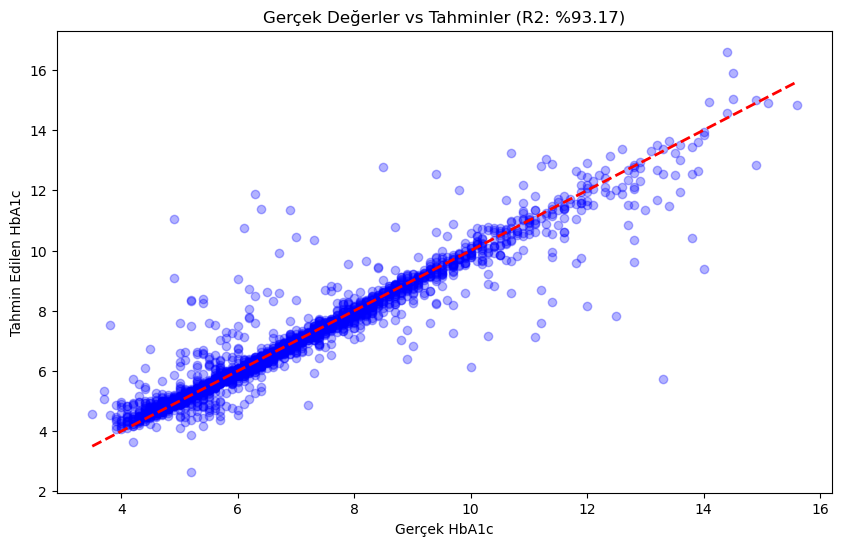

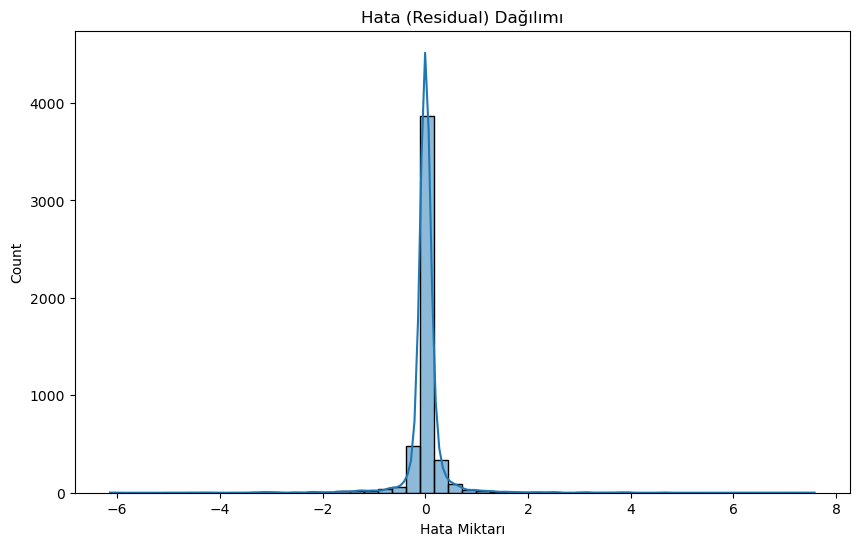

In [ ]:
# Tahminleri alalım
y_pred = reg_model.predict(X_test_scaled)

# Metrikleri hesaplayalım
r2 = r2_score(y_test_reg, y_pred)
mae = mean_absolute_error(y_test_reg, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))

print("--- REGRESYON PERFORMANS RAPORU ---")
print(f"R2 Skoru (Başarı Oranı): %{r2*100:.2f}")
print(f"Ortalama Mutlak Hata (MAE): {mae:.4f} (Örn: 0.2 hata, 6.0 yerine 6.2 tahmin demektir)")
print(f"RMSE: {rmse:.4f}")

# Gerçek vs Tahmin Görselleştirmesi
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred, alpha=0.3, color='blue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], '--r', linewidth=2)
plt.xlabel('Gerçek HbA1c')
plt.ylabel('Tahmin Edilen HbA1c')
plt.title(f'Gerçek Değerler vs Tahminler (R2: %{r2*100:.2f})')
plt.show()

# Hata Dağılımı
errors = y_test_reg - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(errors, bins=50, kde=True)
plt.title("Hata (Residual) Dağılımı")
plt.xlabel("Hata Miktarı")
plt.show()

--- KATEGORİK BAŞARI RAPORU ---
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.95      2321
 Pre-Diyabet       0.91      0.87      0.89      1368
     Diyabet       0.96      0.94      0.95      1350

    accuracy                           0.94      5039
   macro avg       0.94      0.93      0.93      5039
weighted avg       0.94      0.94      0.94      5039

--- OVERFITTING ANALİZİ ---
Eğitim R2: %99.01 | Test R2: %93.17
Genelleme Farkı: %5.84

--- 5-FOLD CROSS VALIDATION ---
CV R2 Skorları: [0.94418068 0.95024293 0.92954073 0.93281318 0.91268213]
Ortalama CV R2: %93.39


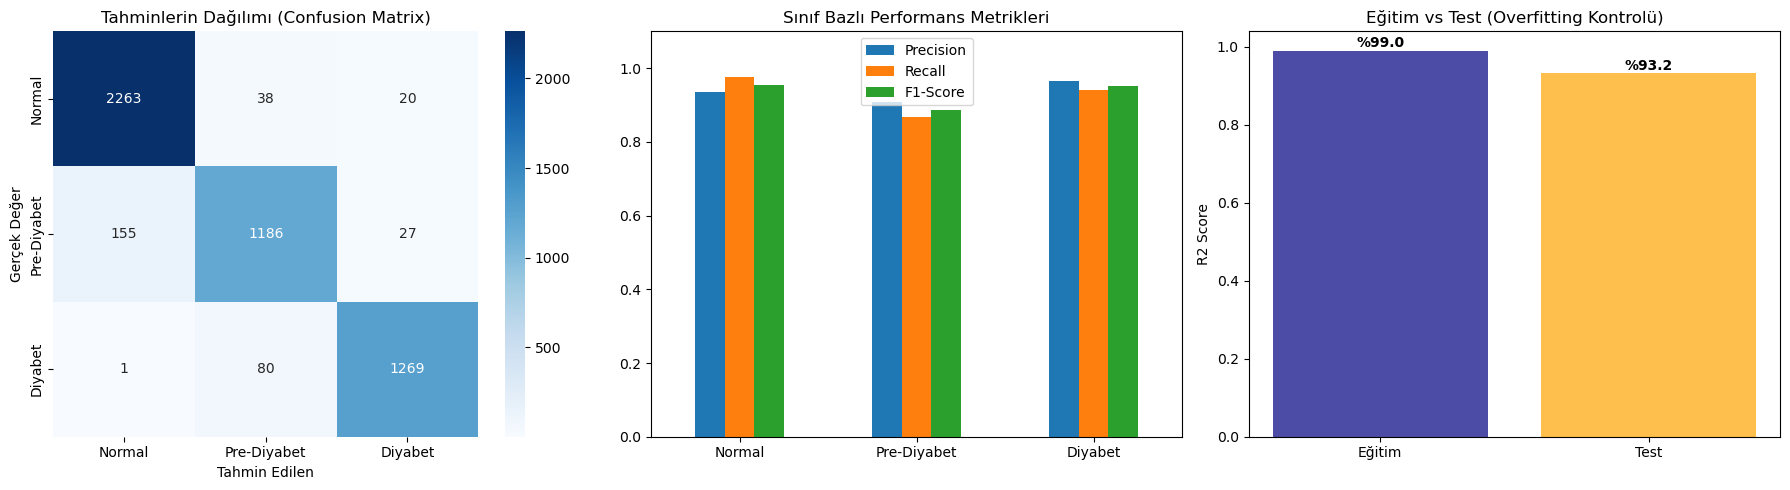

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tahminleri ve Gerçek Değerleri Kategorize Etme (Tıbbi Sınırlar)
def get_label(val):
    if val < 5.7: return 0    # Normal
    elif val < 6.5: return 1  # Pre-Diyabet
    else: return 2            # Diyabet

# Değişkenlerin tanımlı olduğundan emin olalım (Gerekirse yeniden atayalım)
# reg_model'in tanımlı olduğundan emin olmak için Hücre 6'yı çalıştırdığından emin ol!
y_test_reg = df_final.loc[X_test.index, 'Hemoglobin (Hb A1c)']
y_train_reg = df_final.loc[X_train.index, 'Hemoglobin (Hb A1c)']
y_pred = reg_model.predict(X_test_scaled)
y_train_pred = reg_model.predict(X_train_scaled)

y_test_cat = [get_label(x) for x in y_test_reg]
y_pred_cat = [get_label(x) for x in y_pred]
target_names = ['Normal', 'Pre-Diyabet', 'Diyabet']

# 2. Metriklerin Hesaplanması
print("--- KATEGORİK BAŞARI RAPORU ---")
print(classification_report(y_test_cat, y_pred_cat, target_names=target_names))

# 3. Overfitting Analizi
train_r2 = r2_score(y_train_reg, y_train_pred)
test_r2 = r2_score(y_test_reg, y_pred)
print(f"--- OVERFITTING ANALİZİ ---")
print(f"Eğitim R2: %{train_r2*100:.2f} | Test R2: %{test_r2*100:.2f}")
print(f"Genelleme Farkı: %{abs(train_r2 - test_r2)*100:.2f}")

# 4. 5-Fold Cross Validation (Kararlılık Testi)
print(f"\n--- 5-FOLD CROSS VALIDATION ---")
X_scaled_all = scaler.fit_transform(X)
cv_scores = cross_val_score(reg_model, X_scaled_all, df_final['Hemoglobin (Hb A1c)'], cv=5, scoring='r2')
print(f"CV R2 Skorları: {cv_scores}")
print(f"Ortalama CV R2: %{cv_scores.mean()*100:.2f}")

# 5. GÖRSEL ANALİZ PANELİ
plt.figure(figsize=(18, 5))

# A. Confusion Matrix (Karmaşıklık Matrisi)
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test_cat, y_pred_cat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Tahminlerin Dağılımı (Confusion Matrix)')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')

# B. Metriklerin Görselleştirilmesi (Precision, Recall, F1)
plt.subplot(1, 3, 2)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_cat, y_pred_cat)
metrics_df = pd.DataFrame({'Precision': precision, 'Recall': recall, 'F1-Score': f1}, index=target_names)
metrics_df.plot(kind='bar', ax=plt.gca())
plt.title('Sınıf Bazlı Performans Metrikleri')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)

# C. Overfitting - Eğitim vs Test Hatası
plt.subplot(1, 3, 3)
plt.bar(['Eğitim', 'Test'], [train_r2, test_r2], color=['navy', 'orange'], alpha=0.7)
plt.title('Eğitim vs Test (Overfitting Kontrolü)')
plt.ylabel('R2 Score')
for i, v in enumerate([train_r2, test_r2]):
    plt.text(i, v + 0.01, f"%{v*100:.1f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Overfitting'i engellemek için parametre uzayını daraltalım
param_grid = {
    'n_estimators': [300, 500, 800],
    'max_depth': [4, 5, 6], # Derinliği azalttık (overfitting çözümü)
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

# Modeli optimize edelim
random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, objective='reg:squarederror'),
    param_distributions=param_grid,
    n_iter=10, 
    cv=3, 
    scoring='r2', 
    verbose=1, 
    n_jobs=-1
)

print("En iyi parametreler aranıyor...")
random_search.fit(X_train_scaled, y_train_reg)

# En iyi modeli seçelim
best_model = random_search.best_estimator_
print(f"En iyi parametreler: {random_search.best_params_}")

# Yeni tahminler ve performans farkı
new_test_r2 = best_model.score(X_test_scaled, y_test_reg)
new_train_r2 = best_model.score(X_train_scaled, y_train_reg)
print(f"Yeni Eğitim R2: %{new_train_r2*100:.2f}")
print(f"Yeni Test R2: %{new_test_r2*100:.2f}")
print(f"Yeni Fark: %{abs(new_train_r2 - new_test_r2)*100:.2f}")

En iyi parametreler aranıyor...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
En iyi parametreler: {'subsample': 0.7, 'n_estimators': 800, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Yeni Eğitim R2: %96.55
Yeni Test R2: %93.65
Yeni Fark: %2.90


--- OPTİMİZE EDİLMİŞ MODEL METRİKLERİ ---
Yeni Genel Doğruluk (Accuracy): %91.05

Yeni Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Normal       0.91      0.97      0.94      2321
 Pre-Diyabet       0.87      0.80      0.84      1368
     Diyabet       0.95      0.92      0.94      1350

    accuracy                           0.91      5039
   macro avg       0.91      0.90      0.90      5039
weighted avg       0.91      0.91      0.91      5039



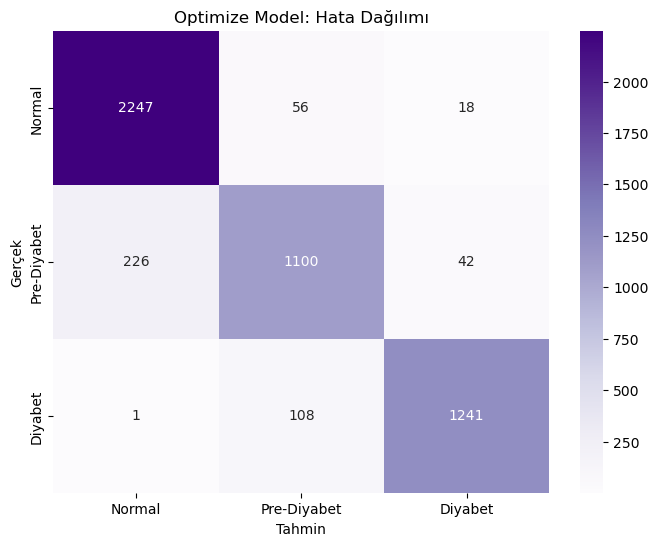

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Yeni en iyi modelle tahminleri alalım
y_pred_best = best_model.predict(X_test_scaled)

# Kategorize edelim
y_test_cat = [get_label(x) for x in y_test_reg]
y_pred_cat_best = [get_label(x) for x in y_pred_best]
target_names = ['Normal', 'Pre-Diyabet', 'Diyabet']

print("--- OPTİMİZE EDİLMİŞ MODEL METRİKLERİ ---")
print(f"Yeni Genel Doğruluk (Accuracy): %{accuracy_score(y_test_cat, y_pred_cat_best)*100:.2f}")
print("\nYeni Sınıflandırma Raporu:")
print(classification_report(y_test_cat, y_pred_cat_best, target_names=target_names))

# Confusion Matrix Görselleştirme
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_cat, y_pred_cat_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=target_names, yticklabels=target_names)
plt.title('Optimize Model: Hata Dağılımı')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.show()

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Regresyon hedefimizi (HbA1c) geçici olarak kategorize edelim ki 
# hangi aralıklardan veri üreteceğimizi ROS'a anlatabilelim
y_train_cat_temp = [get_label(x) for x in y_train_reg]

print(f"Artırma Öncesi Eğitim Seti Dağılımı: {Counter(y_train_cat_temp)}")

# 1. Veri Artırma (Oversampling)
# Sadece eğitim verisindeki azınlık sınıfları 'Normal' sayısı kadar çoğaltıyoruz
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled_labels = ros.fit_resample(X_train_scaled, y_train_cat_temp)

# 2. Önemli: Regresyon değerlerini (HbA1c) yeni örneklere geri kazandırmalıyız
# Rastgele örnekleme yaptığımız için orijinal indisleri kullanarak gerçek HbA1c değerlerini çekiyoruz
resampled_indices = ros.sample_indices_
y_train_reg_resampled = y_train_reg.iloc[resampled_indices]

print(f"Artırma Sonrası Eğitim Seti Dağılımı: {Counter(y_train_resampled_labels)}")

# 3. Modeli Yeni (Dengelenmiş) Veriyle Tekrar Eğitme
# Parametreleri bir önceki adımda bulduğumuz en iyi setten alıyoruz
balanced_model = XGBRegressor(
    subsample=0.7, 
    n_estimators=800, 
    max_depth=4, 
    learning_rate=0.05, 
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

balanced_model.fit(X_train_resampled, y_train_reg_resampled)
print("\nDengelenmiş veriyle model eğitimi tamamlandı.")

Artırma Öncesi Eğitim Seti Dağılımı: Counter({0: 9282, 1: 5474, 2: 5400})
Artırma Sonrası Eğitim Seti Dağılımı: Counter({2: 9282, 1: 9282, 0: 9282})

Dengelenmiş veriyle model eğitimi tamamlandı.


--- VERİ ARTIRMA SONRASI KLİNİK RAPOR ---
              precision    recall  f1-score   support

      Normal       0.92      0.96      0.94      2321
 Pre-Diyabet       0.87      0.83      0.85      1368
     Diyabet       0.95      0.92      0.94      1350

    accuracy                           0.91      5039
   macro avg       0.91      0.90      0.91      5039
weighted avg       0.91      0.91      0.91      5039



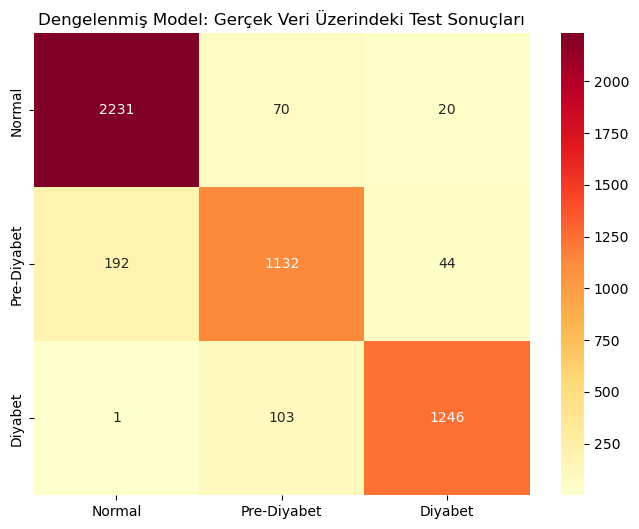

In [ ]:
# Yeni tahminler
y_pred_balanced = balanced_model.predict(X_test_scaled)
y_pred_cat_balanced = [get_label(x) for x in y_pred_balanced]

print("--- VERİ ARTIRMA SONRASI KLİNİK RAPOR ---")
print(classification_report(y_test_cat, y_pred_cat_balanced, target_names=target_names))

# Görsel farkı görelim
plt.figure(figsize=(8, 6))
cm_balanced = confusion_matrix(y_test_cat, y_pred_cat_balanced)
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='YlOrRd', xticklabels=target_names, yticklabels=target_names)
plt.title('Dengelenmiş Model: Gerçek Veri Üzerindeki Test Sonuçları')
plt.show()

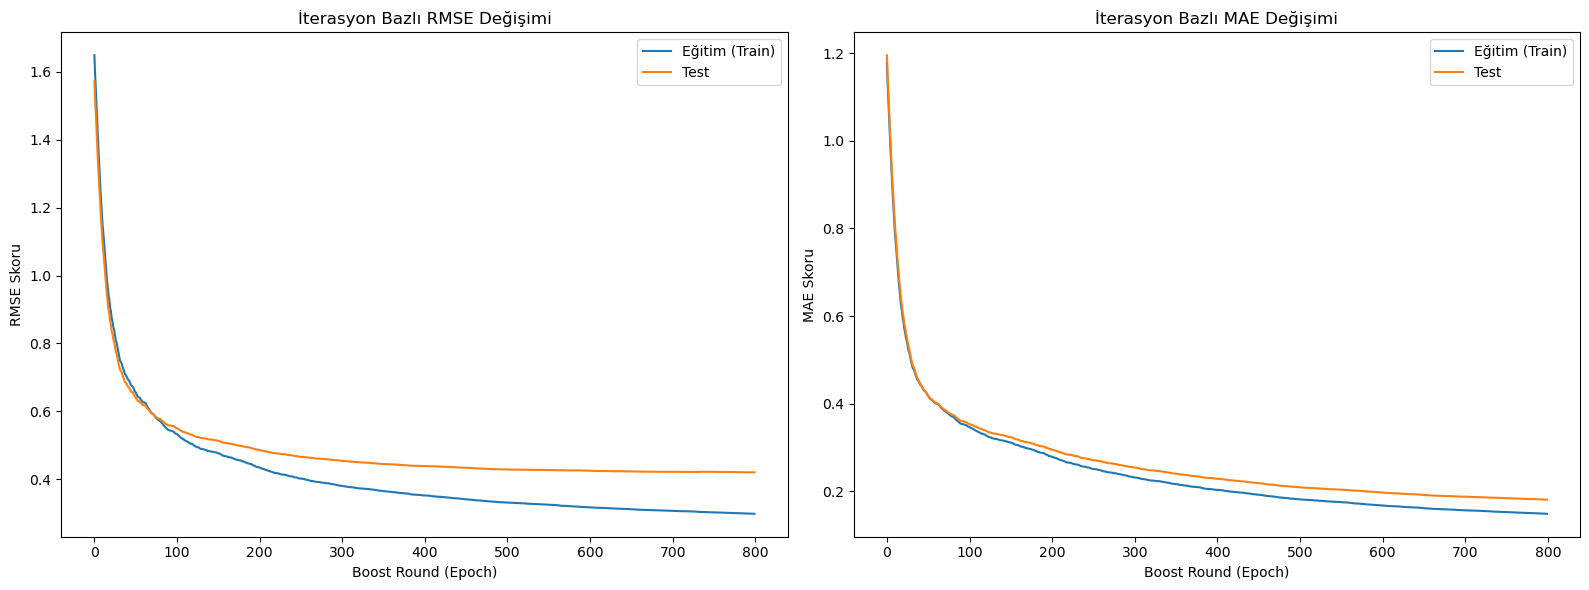

Final Test MAE: 0.1814
Final Test RMSE: 0.4202


In [ ]:
import matplotlib.pyplot as plt

# İzlemek istediğimiz metrikleri tanımlayarak modeli tekrar tanımlayalım
eval_model = XGBRegressor(
    subsample=0.7, 
    n_estimators=800, # 800 iterasyon
    max_depth=4, 
    learning_rate=0.05, 
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    eval_metric=["rmse", "mae"] # Takip edilecek metrikler
)

# Eğitimi eval_set ile başlatalım ki gelişim kaydedilsin
eval_model.fit(
    X_train_resampled, y_train_reg_resampled,
    eval_set=[(X_train_resampled, y_train_reg_resampled), (X_test_scaled, y_test_reg)],
    verbose=False
)

# Metrik sonuçlarını çekelim
results = eval_model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

# Grafikleri çizelim
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. RMSE Grafiği
ax[0].plot(x_axis, results['validation_0']['rmse'], label='Eğitim (Train)')
ax[0].plot(x_axis, results['validation_1']['rmse'], label='Test')
ax[0].set_title('İterasyon Bazlı RMSE Değişimi')
ax[0].set_xlabel('Boost Round (Epoch)')
ax[0].set_ylabel('RMSE Skoru')
ax[0].legend()

# 2. MAE Grafiği
ax[1].plot(x_axis, results['validation_0']['mae'], label='Eğitim (Train)')
ax[1].plot(x_axis, results['validation_1']['mae'], label='Test')
ax[1].set_title('İterasyon Bazlı MAE Değişimi')
ax[1].set_xlabel('Boost Round (Epoch)')
ax[1].set_ylabel('MAE Skoru')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Final Test MAE: {results['validation_1']['mae'][-1]:.4f}")
print(f"Final Test RMSE: {results['validation_1']['rmse'][-1]:.4f}")

In [ ]:
# Modeli XGBoost'un önerdiği güvenli formatta kaydet
eval_model.save_model('aidcare_hba1c_model.json')

# Scaler için joblib kullanmaya devam edebiliriz (ama versiyonlar aynı olmalı)
import joblib
joblib.dump(scaler, 'aidcare_scaler.pkl')

print("Model .json formatında, Scaler .pkl formatında kaydedildi.")

Model .json formatında, Scaler .pkl formatında kaydedildi.


In [ ]:
%pip install tensorflow keras-tuner

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached keras_tuner-1.4.8-py3-none-any.whl.metadata (5.6 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached grpcio-1.80.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using c

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.



   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 73.9/351.2 MB 116.9 kB/s eta 0:39:33
   -------- ------------------------------ 74.2/351.2 MB 114.7 kB/s eta 0:40:16
   -------- ---------------------------

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import shutil
import os

import sys
# Tensorboard varmış gibi davranması için boş bir modül simülasyonu (hack)
from unittest.mock import MagicMock
sys.modules["tensorboard"] = MagicMock()
sys.modules["tensorboard.plugins"] = MagicMock()
sys.modules["tensorboard.plugins.hparams"] = MagicMock()

# 1. Eski denemeleri ve kilit dosyalarını temizleyelim
if os.path.exists('aidcare_expert_tuning'):
    try:
        shutil.rmtree('aidcare_expert_tuning')
    except:
        pass

# 2. Model Mimarisi (Aynı kalıyor)
def build_model(hp):
    model = keras.Sequential()
    for i in range(hp.Int('num_layers', 2, 6)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=64, max_value=512, step=64),
            activation=hp.Choice('activation', values=['relu', 'swish', 'elu'])
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(hp.Float('dropout', 0.1, 0.4, step=0.1)))
    
    model.add(layers.Dense(1)) 
    
    opt_name = hp.Choice('optimizer', values=['adam', 'nadam', 'rmsprop'])
    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    
    if opt_name == 'adam': optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == 'nadam': optimizer = keras.optimizers.Nadam(learning_rate=lr)
    else: optimizer = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# 3. Tuner Ayarı (Kritik nokta: logger'ı manuel engelliyoruz)
# Logger sınıflarını devre dışı bırakmak için boş bir liste veya özel ayar geçiyoruz
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_loss',
    max_trials=25,
    directory='aidcare_expert_tuning',
    project_name='hba1c_master_final',
    overwrite=True
)

# 4. Arama (Sadece EarlyStopping callback'i ile)
stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=12, 
    restore_best_weights=True
)

print("AIDCARE Expert Tuner Başlatılıyor... En iyisi biz olacağız.")

# search() fonksiyonuna ek bir logger callback'i gitmediğinden emin oluyoruz
tuner.search(
    X_train_resampled, 
    y_train_reg_resampled, 
    epochs=150, 
    validation_split=0.2, 
    callbacks=[stop_early], 
    verbose=1
)

# En iyi parametreleri yazdır
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n" + "="*30)
print("ŞAMPİYON MİMARİ BULUNDU!")
print(f"Katman: {best_hps.get('num_layers')}")
print(f"Optimizer: {best_hps.get('optimizer')}")
print(f"Aktivasyon: {best_hps.get('activation')}")
print(f"Öğrenme Oranı: {best_hps.get('learning_rate')}")
print("="*30)

Trial 25 Complete [00h 01m 33s]
val_loss: 0.1530059278011322

Best val_loss So Far: 0.1317969411611557
Total elapsed time: 00h 48m 11s

ŞAMPİYON MİMARİ BULUNDU!
Katman: 2
Optimizer: rmsprop
Aktivasyon: elu
Öğrenme Oranı: 0.0012129560775108322
